<a href="https://colab.research.google.com/github/pkolenic/pytorch-video-learning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Fundamentals

Let's explore an example PyTorch end-to-end workflow.

Resources:
- Ground truth notebook - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
- Book version of notebook - https://www.learnpytorch.io/01_pytorch_workflow/
- Ask a question - https://github.com/mrdbourke/pytorch-deep-learning/discussions

In [343]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together",
                      }

In [344]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.9.0+cu126'

## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos (YouTube has lots of data...)
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the linear regresssion formula.

We'll use a linear regression formula to make a straight line with *known* **parameters**.

`y=a+bx`: This is the general equation for a linear relationship.
* `y`: The dependent variable, or the value you are trying to predict.
* `x`: The independent variable, which you use to make the prediction.
* `a`: The y-intercept, or the value of `y` when `x` is zero.
* `b`: The slope of the line, which indicates how much `y` is expected to change for a one-unit change in `x`.



In [345]:
import torch

# Create *known* parameters
weight = 0.7 # b in y=a+bx
bias = 0.3 # a in y=a+bx

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [346]:
len(X), len(y)

(50, 50)

### Splitting data into learning and test sets (one of the most important concepts in machine learning in general)

| Split | Purpose | Amount of total data| How often is it used?|
| :------ | :------ | :------: | :------: |
| **Training Set** | The model learns from this data (like the course materials you study during the semester). | ~60-80% | Always |
| **Validation Set** | The model gets tuned on this data(like the practice exam you take before the final exam). | ~10-20% | Often but not always |
| **Test Set** | The model gets evaluatated on this data to test what it has learned (like the final exam you take at the end of the semester). | ~10-20% | Always |


Let's create a training and test set with our data


In [347]:
# Create a train/test split
train_split = int(0.8 * len(X))
train_split

40

In [348]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [349]:
import matplotlib.pyplot as plt

def plot_predications(train_data=X_train,
                      train_labels=y_train,
                      test_data=X_test,
                      test_labels=y_test,
                      predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot testing data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Are there predictions/
  if predictions is not None:
    # Plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

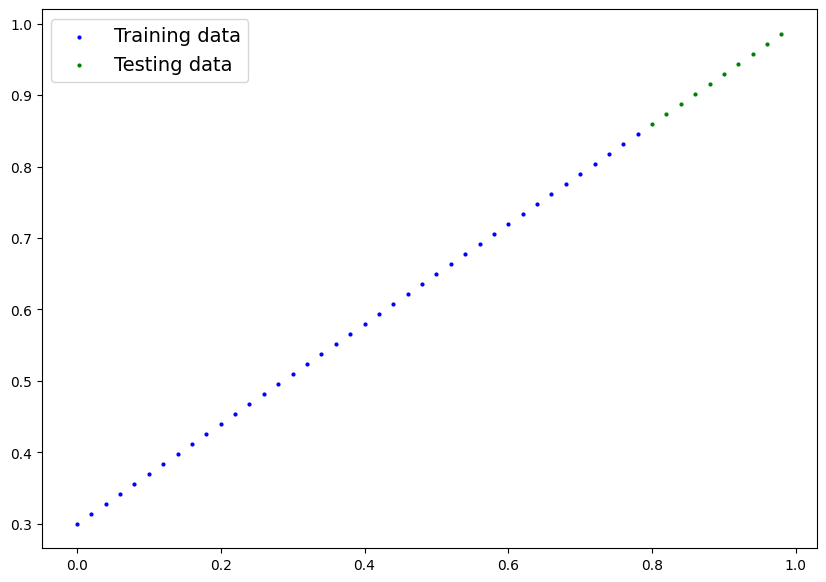

In [350]:
plot_predications()

## 2. Build model

Our first PyTorch model!

This is very exciting... let's do it

What our model dos:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w
2. Backpropagation - https://youtu.be/Ilg3gGewQ5U

In [351]:
import torch
from torch import nn


# Create a linear regression model class
class LinearRegressionModel(nn.Module):  # <- almost everything in PyTorch inherits from nn.Module
  def __init__(self):
      super().__init__()
      self.weights = nn.Parameter(
          torch.randn(
              1, # start with a random weight and try to adjust it to the ideal weight
              requires_grad=True, # can this parameter be updated via gradient descent?
              dtype=torch.float, # PyTorch loves the datatype torch.float32
          )
      )
      self.bias = nn.Parameter(
          torch.randn(
              1, # start with a random bias and try to adjust it to the ideal bias
              requires_grad=True,  # can this parameter be updated via gradient descent?
              dtype=torch.float,  # PyTorch loves the datatype torch.float32
          )
      )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
      """
      Defines the computation in the model
      :param x: The input data
      :return: The linear regression formula applied to the input data
      """
      return self.weights * x + self.bias  # this is the linear regression formula


### PyTorch model building essentials

* torch.nn - contains all of the buiding blocks for computational graphs (a neural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation


### Checking the contents of our PyTorch model

Now we've create a model, let's see what's inside...

So we can check out our model's parameters or what's inside our model using `.parameters()`

In [352]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [353]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` base on `X_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [354]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

See more on inference mode here - https://x.com/PyTorch/status/1437838231505096708

`torch.inference_mode()` is a replacement for `torch.no_grad()`

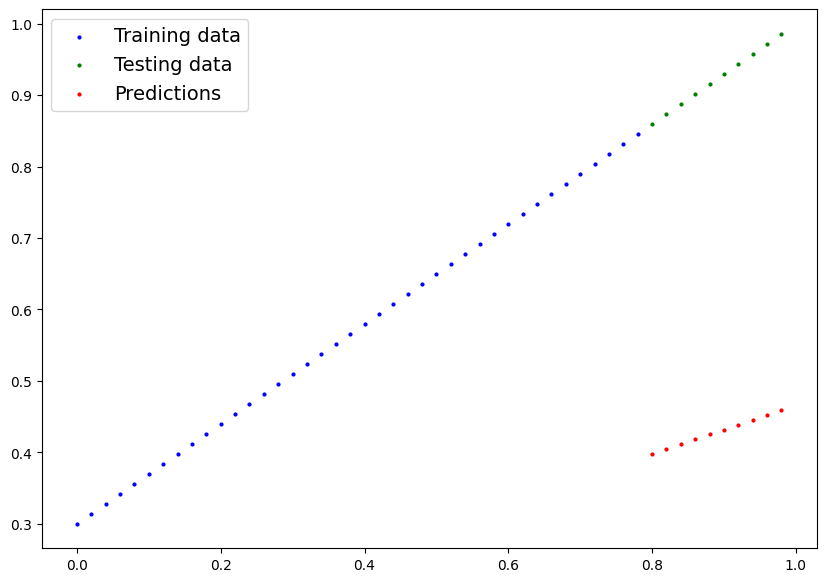

In [355]:
plot_predications(predictions=y_preds)

## 3. Train Model

The whole idea of traning is for a model to move from some *unknown* parameters (theses may be random) to some *known* parameters.

Or in other words from a poor representation of the data to a better representation of the day.

One way to measure how poor or how wrong you models predicictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas.  For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower are better. https://docs.pytorch.org/docs/stable/nn.html#loss-functions


* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function. https://docs.pytorch.org/docs/stable/optim.html
  * Inside the optimizer you'll oten have to set two parameters:
    * `params` - the model parameters you'd like to optimze for example `params=model_0.parameters()
    * `lr` (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` results in small changes, a large `lr` results in large changes)

And specifically for PyTorch, we need:
* A training loop
* A testing loop


In [356]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [357]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [358]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(
  params=model_0.parameters(),
  lr=0.01, # lr = learning rate = possible the most important hyperparameter you can set
)

**Q**: Which loss function and optimizer should I use?

**A**: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data and do...
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called foward propagation
2. Calculate the loss (compare foward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation** - https://www.youtube.com/watch?v=tIeHLnjs5U8)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent** - https://youtu.be/IHZwWFHWa-w)


In [359]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [360]:
from re import L
torch.manual_seed(42)

# And epoch is one loop through the data... (this is a hyperparameter because we've set it ourselves)
epochs = 250
epoch_rut_size = 25
last_training_losses = []
last_test_losses = []
epochs_run = 0
loss = None

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

### Training
# 0. Loop through the data
for epoch in range(epochs):
  epochs_run += 1
  # Set the model to training mode
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad - zero out the gradients
  optimizer.zero_grad()

  # 4. Loss backward - Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step() # by default hot the optimizer changes will acculumate through the loop so... we have to zero them above in step 3 for the next iteration of the loop

  ### Testing
  # Put the model in evaluation mode
  model_0.eval() # turns off gradient tracking / # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

  with torch.inference_mode(): # turns off gradient tracking & a couple more things behind the scenes - https://twitter.com/PyTorch/status/1437838231505096708?s=20&t=aftDZicoiUGiklEP179x7A
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

  # Store data for graphing
  epoch_count.append(epoch)
  train_loss_values.append(loss.detach().numpy())
  test_loss_values.append(test_loss.detach().numpy())

  # Print out what's happening
  if epoch % 10 == 0:
        print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
        print(model_0.state_dict())

  # Add the latest loss to the list of losses to determine if we are stuck in a rut
  last_training_losses.append(loss.item())
  last_test_losses.append(test_loss.item())

  # If any of the last losses are duplicated then we need to break as we're stuck in a rut
  if len(last_test_losses) != len(set(last_test_losses)):
    break

  # Truncate the last_losses to the epoch_rut_size
  last_training_losses = last_training_losses[-epoch_rut_size:]
  last_test_losses = last_test_losses[-epoch_rut_size:]

# Print the results
print(f"\nIt took {epochs_run} epochs before it stablized")
print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} \n")
print(model_0.state_dict())

#  list of last_losses
print(f"Training losses {last_training_losses}")
print(f"Test losses {last_test_losses}")

# Should we bail if the loss gets worse? ... maybe not as it could be in a local minimum
# But how to go back to a better outcome after bailing from being in a rut?


Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886

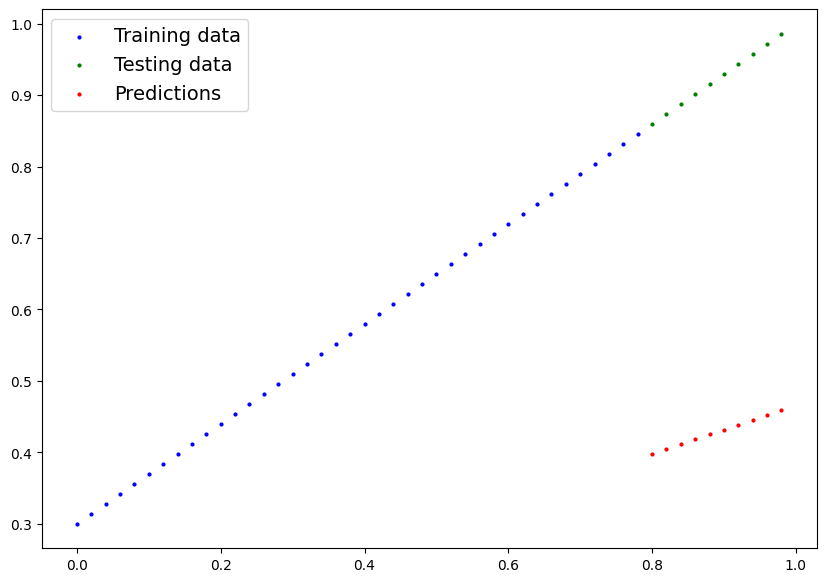

In [361]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)
plot_predications(predictions=y_preds)

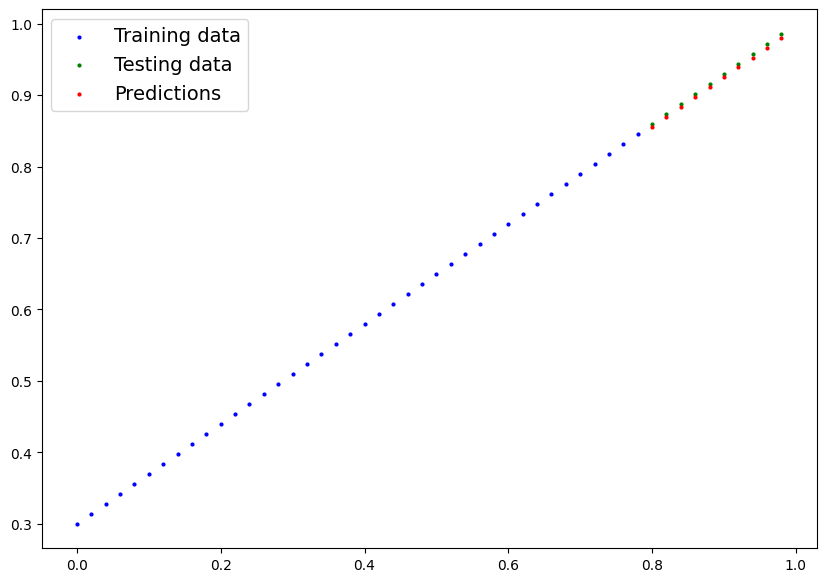

In [362]:
plot_predications(predictions=y_preds_new)

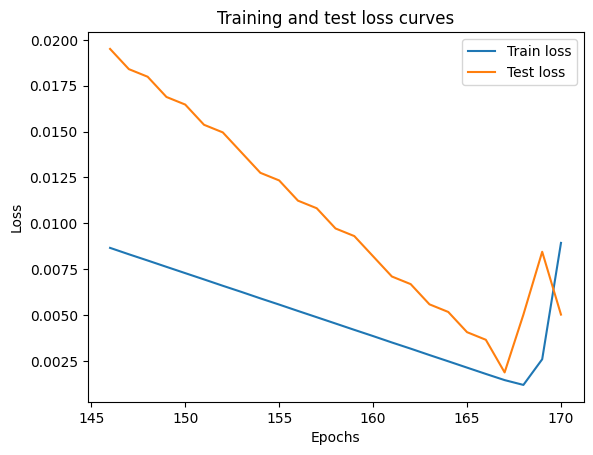

In [363]:
# Plot the loss curves
plt.plot(epoch_count[-25:], train_loss_values[-25:], label="Train loss")
plt.plot(epoch_count[-25:], test_loss_values[-25:], label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();